# Determination of Wind Speeds in Hamburg on February 18, 2022

In [6]:
import cdsapi
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.ticker as mticker
import geopandas as gpd

## Download + visualization of the hourly data from ERA5

In [3]:
c = cdsapi.Client()

c.retrieve(
    'reanalysis-era5-single-levels',
    {
        'product_type': 'reanalysis',
        'variable': [
            '10m_u_component_of_wind',
            '10m_v_component_of_wind',
        ],
        'year': '2022',
        'month': '02',
        'day': '18',
        'time': [f"{h:02d}:00" for h in range(24)],  # hourly
        'format': 'netcdf',
        'area': [54.5, 8.5, 52.5, 11.5],  # N, W, S, E (tight bounding box around Hamburg)
        'grid': [0.25, 0.25],  # ERA5 native resolution
    },
    'data/hamburg_wind_20220218_bigger_area.nc'
)


2025-05-12 10:38:58,200 INFO [2024-09-26T00:00:00] Watch our [Forum](https://forum.ecmwf.int/) for Announcements, news and other discussed topics.
2025-05-12 10:38:58,200 WARNING [2024-06-16T00:00:00] CDS API syntax is changed and some keys or parameter names may have also changed. To avoid requests failing, please use the "Show API request code" tool on the dataset Download Form to check you are using the correct syntax for your API request.
2025-05-12 10:38:58,735 INFO Request ID is a136f069-530f-4edd-8150-9242c87cf504
2025-05-12 10:38:58,839 INFO status has been updated to accepted
2025-05-12 10:39:31,667 INFO status has been updated to running
2025-05-12 10:39:48,847 INFO status has been updated to successful


61d9bd73585b50375eadb6436c0201af.nc:   0%|          | 0.00/46.5k [00:00<?, ?B/s]

'data/hamburg_wind_20220218_bigger_area.nc'

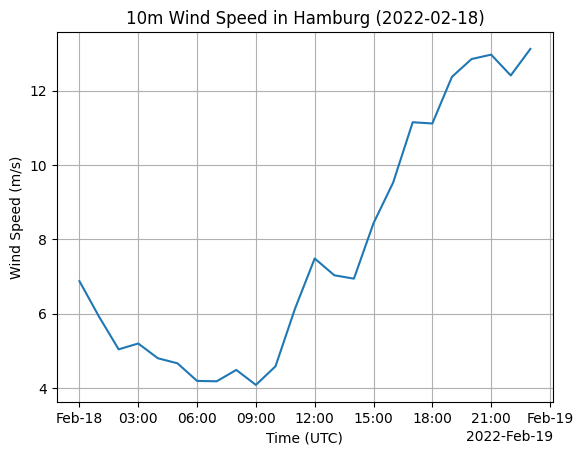

In [3]:
ds = xr.open_dataset("data/hamburg_wind_20220218.nc")

# Compute wind speed
u = ds['u10']
v = ds['v10']
wind_speed = np.sqrt(u**2 + v**2)

# Select the grid point closest to Hamburg (lat, lon)
hamburg_point = wind_speed.sel(latitude=53.55, longitude=10.00, method='nearest')

# Plot wind speed over time
hamburg_point.plot()
plt.title("10m Wind Speed in Hamburg (2022-02-18)")
plt.ylabel("Wind Speed (m/s)")
plt.xlabel("Time (UTC)")
plt.grid(True)
plt.show()

## Show selected region

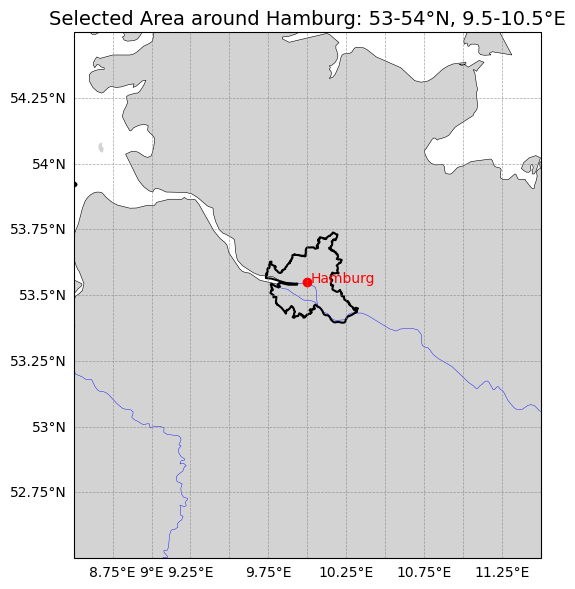

In [7]:
# Load Hamburg boundary from GADM Level 2 shapefile
gdf = gpd.read_file("data/gadm41_DEU_2.json")
hamburg_shape = gdf[gdf["NAME_1"] == "Hamburg"]

# Plot setup
fig = plt.figure(figsize=(8, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

# Set extent to match desired view
ax.set_extent([8.5, 11.5, 52.5, 54.5], crs=ccrs.PlateCarree())

# Add base map features
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.BORDERS, linewidth=0.4)
ax.add_feature(cfeature.COASTLINE, linewidth=0.4)
ax.add_feature(cfeature.RIVERS, edgecolor='blue', linewidth=0.3)

# Plot Hamburg boundary
hamburg_shape.boundary.plot(ax=ax, edgecolor="black", linewidth=1.5, transform=ccrs.PlateCarree())

# Mark Hamburg city center
ax.plot(10.0, 53.55, 'ro', markersize=6, transform=ccrs.PlateCarree())
ax.text(10.02, 53.55, "Hamburg", color='red', transform=ccrs.PlateCarree())

# Gridlines with lat/lon ticks
gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.7, linestyle='--')
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {"size": 10}
gl.ylabel_style = {"size": 10}
gl.xlocator = mticker.MultipleLocator(0.25)
gl.ylocator = mticker.MultipleLocator(0.25)

# Title
plt.title("Selected Area around Hamburg: 53-54°N, 9.5-10.5°E", fontsize=14)
plt.tight_layout()
plt.show()